# Библиотеки

In [11]:
from pprint import pprint

import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, BernoulliRBM
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.datasets import load_wine

import seaborn as sns

## 11.17 Болцмановские машины (RBM): без учителя

In [3]:
d = load_wine()

X = d.data  # числовые признаки, 13 столбцов
y = d.target # зависимая\целевая переменная с метками реальных 3 марок вина

In [8]:
X_s = MinMaxScaler().fit_transform(X)

In [9]:
rbm = BernoulliRBM(n_components=10) 

rbm.fit(X_s)

,"n_components n_components: int, default=256Number of binary hidden units.",10
,"learning_rate learning_rate: float, default=0.1The learning rate for weight updates. It is *highly* recommendedto tune this hyper-parameter. Reasonable values are in the10**[0., -3.] range.",0.1
,"batch_size batch_size: int, default=10Number of examples per minibatch.",10
,"n_iter n_iter: int, default=10Number of iterations/sweeps over the training dataset to performduring training.",10
,"verbose verbose: int, default=0The verbosity level. The default, zero, means silent mode. Rangeof values is [0, inf].",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for:- Gibbs sampling from visible and hidden layers.- Initializing components, sampling from layers during fit.- Corrupting the data when scoring samples.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [10]:
X_rbm = rbm.transform(X_s)

In [12]:
pca = PCA(n_components=2)

X_2d = pca.fit_transform(X_rbm)

In [13]:
d2d = pd.DataFrame(X_2d, columns=['T1', 'T2'])

d2d['Class'] = y

<Axes: xlabel='T1', ylabel='T2'>

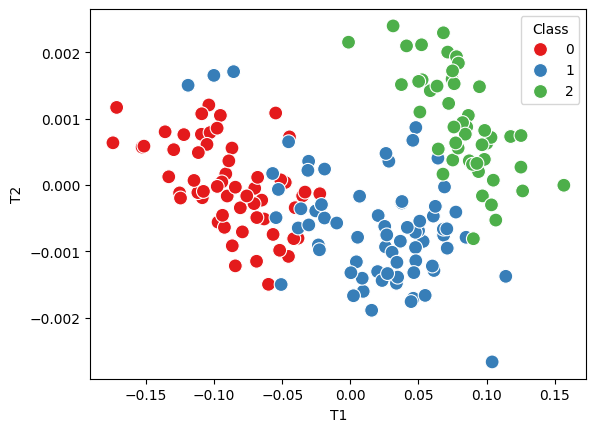

In [14]:
sns.scatterplot(data=d2d, x='T1', y='T2', hue='Class', palette='Set1', s=100)